In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Load Dataset

In [2]:
df = pd.read_csv("../data/smart_grid_dataset.csv")
df.head()

,Timestamp,Voltage (V),Current (A),Power Consumption (kW),Reactive Power (kVAR),Power Factor,Solar Power (kW),Wind Power (kW),Grid Supply (kW),Voltage Fluctuation (%),Overload Condition,Transformer Fault,Temperature (°C),Humidity (%),Electricity Price (USD/kWh),Predicted Load (kW)
0,2024-01-01 00:00:00,232.483571,5.124673,1.191402,0.399029,0.907766,46.614845,26.399566,0.0,1.055937,0,0,17.842767,64.523353,0.416156,1.233158
1,2024-01-01 00:15:00,229.308678,22.213519,5.093753,1.248030,0.831813,6.907170,18.555011,0.0,-3.910902,1,0,18.753698,49.671940,0.492334,5.247824
2,2024-01-01 00:30:00,233.238443,46.132217,10.759806,2.790464,0.999005,15.477640,12.905025,0.0,-0.197551,0,0,16.719325,48.472769,0.427785,10.580278
3,2024-01-01 00:45:00,237.615149,47.648972,11.322118,1.956965,0.896462,35.746398,28.937129,0.0,2.671921,0,0,15.364564,75.766776,0.487953,11.225946
4,2024-01-01 01:00:00,228.829233,7.410166,1.695663,0.624718,0.870681,27.555038,14.184648,0.0,3.826937,0,0,38.760333,61.384213,0.290078,1.696639


## Shape and columns

In [3]:
df.shape

(50000, 16)

In [4]:
df.columns

Index(['Timestamp', 'Voltage (V)', 'Current (A)', 'Power Consumption (kW)',
       'Reactive Power (kVAR)', 'Power Factor', 'Solar Power (kW)',
       'Wind Power (kW)', 'Grid Supply (kW)', 'Voltage Fluctuation (%)',
       'Overload Condition', 'Transformer Fault', 'Temperature (°C)',
       'Humidity (%)', 'Electricity Price (USD/kWh)', 'Predicted Load (kW)'],
      dtype='object')

## Missing values and duplicates

In [5]:
df.isnull().sum()

Timestamp                      0
Voltage (V)                    0
Current (A)                    0
Power Consumption (kW)         0
Reactive Power (kVAR)          0
Power Factor                   0
Solar Power (kW)               0
Wind Power (kW)                0
Grid Supply (kW)               0
Voltage Fluctuation (%)        0
Overload Condition             0
Transformer Fault              0
Temperature (°C)               0
Humidity (%)                   0
Electricity Price (USD/kWh)    0
Predicted Load (kW)            0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

## Basic Data Cleaning

In [7]:
df= df.dropna() #drop rows with missing values
df = df.drop_duplicates() #drop duplicate rows
df = df.reset_index(drop=True)  # reset row index after cleaning
df.shape

(50000, 16)

## Conversion of Timestamp

In [8]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"]) #convert timestamp column to datetime format
df = df.sort_values("Timestamp").reset_index(drop=True) #sort the dataframe by timestamp and reset the index
df.head()

,Timestamp,Voltage (V),Current (A),Power Consumption (kW),Reactive Power (kVAR),Power Factor,Solar Power (kW),Wind Power (kW),Grid Supply (kW),Voltage Fluctuation (%),Overload Condition,Transformer Fault,Temperature (°C),Humidity (%),Electricity Price (USD/kWh),Predicted Load (kW)
0,2024-01-01 00:00:00,232.483571,5.124673,1.191402,0.399029,0.907766,46.614845,26.399566,0.0,1.055937,0,0,17.842767,64.523353,0.416156,1.233158
1,2024-01-01 00:15:00,229.308678,22.213519,5.093753,1.248030,0.831813,6.907170,18.555011,0.0,-3.910902,1,0,18.753698,49.671940,0.492334,5.247824
2,2024-01-01 00:30:00,233.238443,46.132217,10.759806,2.790464,0.999005,15.477640,12.905025,0.0,-0.197551,0,0,16.719325,48.472769,0.427785,10.580278
3,2024-01-01 00:45:00,237.615149,47.648972,11.322118,1.956965,0.896462,35.746398,28.937129,0.0,2.671921,0,0,15.364564,75.766776,0.487953,11.225946
4,2024-01-01 01:00:00,228.829233,7.410166,1.695663,0.624718,0.870681,27.555038,14.184648,0.0,3.826937,0,0,38.760333,61.384213,0.290078,1.696639


## Time range check

In [9]:
df["Timestamp"].min(), df["Timestamp"].max() #check the range of the timestamp column

(Timestamp('2024-01-01 00:00:00'), Timestamp('2025-06-04 19:45:00'))

In [10]:
df["Timestamp"].diff().value_counts().head() # check the frequency of the timestamp column

Timestamp
0 days 00:15:00    49999
Name: count, dtype: int64

## Target

In [11]:
TARGET = "Power Consumption (kW)"
df[TARGET].describe() # check the summary statistics of the target column

count    50000.000000
mean         6.320811
std          2.990096
min          1.089178
25%          3.706998
50%          6.340475
75%          8.914134
max         12.103199
Name: Power Consumption (kW), dtype: float64

## Plot of Target

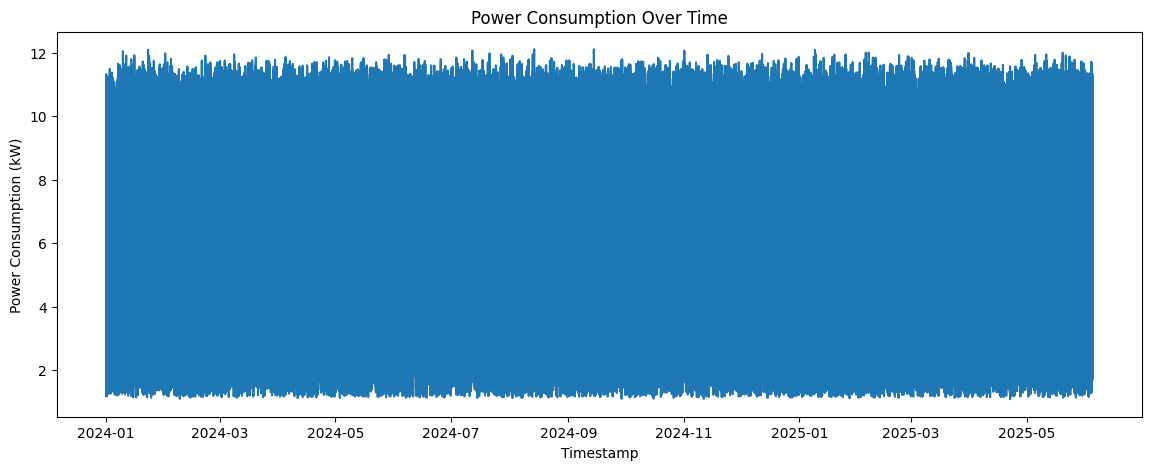

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(df["Timestamp"], df[TARGET])
plt.title("Power Consumption Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Power Consumption (kW)")
plt.show()

## Check overload and fault

In [13]:
df["Overload Condition"].value_counts()  # check overload condition distribution

Overload Condition
0    45044
1     4956
Name: count, dtype: int64

In [14]:
df["Transformer Fault"].value_counts() #  # check transformer fault distribution

Transformer Fault
0    48540
1     1460
Name: count, dtype: int64

## Feature Engineering

In [15]:
df_model = df.copy()  # create a copy of the dataframe for modeling purposes
df_model.head()

,Timestamp,Voltage (V),Current (A),Power Consumption (kW),Reactive Power (kVAR),Power Factor,Solar Power (kW),Wind Power (kW),Grid Supply (kW),Voltage Fluctuation (%),Overload Condition,Transformer Fault,Temperature (°C),Humidity (%),Electricity Price (USD/kWh),Predicted Load (kW)
0,2024-01-01 00:00:00,232.483571,5.124673,1.191402,0.399029,0.907766,46.614845,26.399566,0.0,1.055937,0,0,17.842767,64.523353,0.416156,1.233158
1,2024-01-01 00:15:00,229.308678,22.213519,5.093753,1.248030,0.831813,6.907170,18.555011,0.0,-3.910902,1,0,18.753698,49.671940,0.492334,5.247824
2,2024-01-01 00:30:00,233.238443,46.132217,10.759806,2.790464,0.999005,15.477640,12.905025,0.0,-0.197551,0,0,16.719325,48.472769,0.427785,10.580278
3,2024-01-01 00:45:00,237.615149,47.648972,11.322118,1.956965,0.896462,35.746398,28.937129,0.0,2.671921,0,0,15.364564,75.766776,0.487953,11.225946
4,2024-01-01 01:00:00,228.829233,7.410166,1.695663,0.624718,0.870681,27.555038,14.184648,0.0,3.826937,0,0,38.760333,61.384213,0.290078,1.696639


## Time-based features

In [16]:
df_model["hour"] = df["Timestamp"].dt.hour
df_model["day_of_week"] = df["Timestamp"].dt.dayofweek
df_model["month"] = df["Timestamp"].dt.month
df_model["is_weekend"] = df["Timestamp"].dt.weekday.isin([5, 6]).astype(int)  # create a binary feature for weekend (1 if weekend, 0 if weekday)

df_model[["Timestamp", "hour", "day_of_week", "month", "is_weekend"]].head()  # check the new features


,Timestamp,hour,day_of_week,month,is_weekend
0,2024-01-01 00:00:00,0,0,1,0
1,2024-01-01 00:15:00,0,0,1,0
2,2024-01-01 00:30:00,0,0,1,0
3,2024-01-01 00:45:00,0,0,1,0
4,2024-01-01 01:00:00,1,0,1,0


## Lag features

In [17]:
df_model["lag_1"] = df_model[TARGET].shift(1)  # create a lag feature for the target variable , lag_1 represents the power consumption of the previous 15 minutes
df_model["lag_4"] = df_model[TARGET].shift(4)  # create a lag feature for the target variable , lag_4 represents the power consumption of the previous hour
df_model["lag_96"] = df_model[TARGET].shift(96)  # create a lag feature for the target variable , lag_96 represents the power consumption of same hour the previous day

df_model[["Timestamp", TARGET, "lag_1", "lag_4", "lag_96"]].head(100)  # check the new lag features

,Timestamp,Power Consumption (kW),lag_1,lag_4,lag_96
0,2024-01-01 00:00:00,1.191402,NaN,NaN,NaN
1,2024-01-01 00:15:00,5.093753,1.191402,NaN,NaN
2,2024-01-01 00:30:00,10.759806,5.093753,NaN,NaN
3,2024-01-01 00:45:00,11.322118,10.759806,NaN,NaN
4,2024-01-01 01:00:00,1.695663,11.322118,1.191402,NaN
...,...,...,...,...,...
95,2024-01-01 23:45:00,10.735458,1.735366,9.721159,NaN
96,2024-01-02 00:00:00,8.138699,10.735458,3.732637,1.191402
97,2024-01-02 00:15:00,4.454547,8.138699,7.975778,5.093753
98,2024-01-02 00:30:00,9.151997,4.454547,1.735366,10.759806


## Rolling mean features

In [ ]:
df_model["rolling_mean_4"] = df_model[TARGET].shift(1).rolling(window=4).mean()  # create a rolling mean feature for the target variable with a window of 4 (1 hour), shift before rolling to avoid data leakage
df_model["rolling_mean_24"] = df_model[TARGET].shift(1).rolling(window=24).mean()  # create a rolling mean feature for the target variable with a window of 24 (6 hours)
df_model["rolling_mean_96"] = df_model[TARGET].shift(1).rolling(window=96).mean()  # create a rolling mean feature for the target variable with a window of 96 (24 hours)

df_model[["Timestamp", TARGET, "rolling_mean_4", "rolling_mean_24", "rolling_mean_96"]].head(100)  # check the new rolling mean features

,Timestamp,Power Consumption (kW),rolling_mean_4,rolling_mean_24,rolling_mean_96
0,2024-01-01 00:00:00,1.191402,NaN,NaN,NaN
1,2024-01-01 00:15:00,5.093753,NaN,NaN,NaN
2,2024-01-01 00:30:00,10.759806,NaN,NaN,NaN
3,2024-01-01 00:45:00,11.322118,NaN,NaN,NaN
4,2024-01-01 01:00:00,1.695663,NaN,NaN,NaN
...,...,...,...,...,...
95,2024-01-01 23:45:00,10.735458,9.862609,4.644498,NaN
96,2024-01-02 00:00:00,8.138699,8.249092,4.614144,NaN
97,2024-01-02 00:15:00,4.454547,7.438183,4.707653,NaN
98,2024-01-02 00:30:00,9.151997,5.791235,4.755864,NaN


## Check for missing values after lags

In [19]:
df_model.isna().sum()  # check for missing values after feature engineering

Timestamp                        0
Voltage (V)                      0
Current (A)                      0
Power Consumption (kW)           0
Reactive Power (kVAR)            0
Power Factor                     0
Solar Power (kW)                 0
Wind Power (kW)                  0
Grid Supply (kW)                 0
Voltage Fluctuation (%)          0
Overload Condition               0
Transformer Fault                0
Temperature (°C)                 0
Humidity (%)                     0
Electricity Price (USD/kWh)      0
Predicted Load (kW)              0
hour                             0
day_of_week                      0
month                            0
is_weekend                       0
lag_1                            1
lag_4                            4
lag_96                          96
rolling_mean_4                   7
rolling_mean_24                 47
rolling_mean_96                191
dtype: int64

In [20]:
df_model = df_model.dropna().reset_index(drop=True)  # drop rows with missing values after feature engineering
df_model.shape

(49809, 26)

## Choosing features

In [21]:
FEATURES = [
    "Voltage (V)",
    "Current (A)",
    "Reactive Power (kVAR)",
    "Power Factor",
    "Solar Power (kW)",
    "Wind Power (kW)",
    "Grid Supply (kW)",
    "Voltage Fluctuation (%)",
    "Temperature (°C)",
    "Humidity (%)",
    "Electricity Price (USD/kWh)",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "lag_1",
    "lag_4",
    "lag_96",
    "rolling_mean_4",
    "rolling_mean_24",
    "rolling_mean_96",
]

X = df_model[FEATURES]
y = df_model[TARGET]

X.head()

,Voltage (V),Current (A),Reactive Power (kVAR),Power Factor,Solar Power (kW),Wind Power (kW),Grid Supply (kW),Voltage Fluctuation (%),Temperature (°C),Humidity (%),...,hour,day_of_week,month,is_weekend,lag_1,lag_4,lag_96,rolling_mean_4,rolling_mean_24,rolling_mean_96
0,234.281994,43.490277,2.866273,0.841390,19.838291,20.326211,0.0,-0.568573,20.172521,64.501642,...,23,1,1,0,1.671838,9.147640,10.735458,6.483439,6.508414,5.338170
1,231.070469,34.730447,0.923724,0.929473,9.289614,2.751847,0.0,-1.176978,16.059927,37.577239,...,0,2,1,0,10.188989,8.447813,8.138699,8.095094,6.266496,5.410538
2,223.771306,12.898405,1.123356,0.823146,28.411900,7.594681,0.0,-1.285642,10.164492,23.035462,...,0,2,1,0,8.025181,10.248114,4.454547,9.124853,6.318593,5.403880
3,230.865905,35.707133,1.990696,0.855513,4.979913,18.075053,0.0,1.840720,26.280192,42.776886,...,0,2,1,0,2.886293,1.671838,9.151997,7.378851,6.374651,5.387132
4,231.926587,28.029180,2.156853,0.943400,33.900566,4.770341,0.0,-3.269429,26.146434,66.597010,...,0,2,1,0,8.243560,10.188989,1.306826,7.639188,6.199948,5.282806


In [22]:
y.head()

0    10.188989
1     8.025181
2     2.886293
3     8.243560
4     6.500712
Name: Power Consumption (kW), dtype: float64

## Time-based split

In [23]:
split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((39847, 21), (9962, 21), (39847,), (9962,))

## Quick baseline model

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

baseline_predictions = X_test["lag_1"]

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))

baseline_mae, baseline_rmse

(3.4734226726543285, np.float64(4.251530918851246))

## Train a Baseline Machine Learning Model

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)  # Use all available cores for parallel processing
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))


print(f"Naive Baseline MAE: {baseline_mae:.4f}")
print(f"Naive Baseline RMSE: {baseline_rmse:.4f}")
print(f"Random Forest MAE: {rf_mae:.4f}")
print(f"Random Forest RMSE: {rf_rmse:.4f}")

Naive Baseline MAE: 3.4734
Naive Baseline RMSE: 4.2515
Random Forest MAE: 0.0056
Random Forest RMSE: 0.0111


In [26]:
results_df = pd.DataFrame([{
    "model": "Naive Baseline(lag_1)",
    "mae": baseline_mae,
    "rmse": baseline_rmse},
    
    {"model": "Random Forest",
    "mae": rf_mae,
    "rmse": rf_rmse}])

results_df

,model,mae,rmse
0,Naive Baseline(lag_1),3.473423,4.251531
1,Random Forest,0.005555,0.011118


In [27]:
results_df.sort_values("mae")

,model,mae,rmse
1,Random Forest,0.005555,0.011118
0,Naive Baseline(lag_1),3.473423,4.251531


## Leakage Check

In [28]:
feature_importances = pd.DataFrame({
    "feature": FEATURES,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importances

,feature,importance
1,Current (A),9.975015e-01
0,Voltage (V),2.474983e-03
8,Temperature (°C),1.579667e-06
2,Reactive Power (kVAR),1.568954e-06
7,Voltage Fluctuation (%),1.493759e-06
15,lag_1,1.481843e-06
20,rolling_mean_96,1.467879e-06
19,rolling_mean_24,1.464358e-06
3,Power Factor,1.447335e-06
5,Wind Power (kW),1.441093e-06


In [29]:
correlations = df_model[FEATURES + [TARGET]].corr(numeric_only=True)[TARGET].sort_values(ascending=False)

correlations

Power Consumption (kW)         1.000000
Current (A)                    0.998714
Reactive Power (kVAR)          0.778616
Grid Supply (kW)               0.095460
Voltage (V)                    0.043610
hour                           0.009784
lag_4                          0.007554
lag_96                         0.004734
Electricity Price (USD/kWh)    0.004709
rolling_mean_4                 0.002479
Voltage Fluctuation (%)        0.002146
Humidity (%)                   0.000335
is_weekend                    -0.000423
day_of_week                   -0.000435
Wind Power (kW)               -0.000567
rolling_mean_96               -0.002607
Power Factor                  -0.002897
rolling_mean_24               -0.004213
Temperature (°C)              -0.004683
month                         -0.006147
Solar Power (kW)              -0.008388
lag_1                         -0.009857
Name: Power Consumption (kW), dtype: float64

The first Random Forest model achieved extremely low error. Feature importance and correlation analysis showed that Current (A) dominated the predictions and had a very high correlation with the target variable Power Consumption (kW). This suggests potential leakage or a same-timestamp proxy feature. Therefore, a safer feature set was created for a more realistic forecasting setup.

## Train a Safer Forecasting Model

In [30]:
SAFE_FEATURES = [
    "Solar Power (kW)",
    "Wind Power (kW)",
    "Temperature (°C)",
    "Humidity (%)",
    "Electricity Price (USD/kWh)",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "lag_1",
    "lag_4",
    "lag_96",
    "rolling_mean_4",
    "rolling_mean_24",
    "rolling_mean_96",
]

X_safe = df_model[SAFE_FEATURES]
y = df_model[TARGET]

split_index = int(len(df_model) * 0.8)

X_train_safe = X_safe.iloc[:split_index]
X_test_safe = X_safe.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

X_train_safe.shape, X_test_safe.shape

((39847, 15), (9962, 15))

In [31]:
rf_safe_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_safe_model.fit(X_train_safe, y_train)

rf_safe_predictions = rf_safe_model.predict(X_test_safe)

rf_safe_mae = mean_absolute_error(y_test, rf_safe_predictions)
rf_safe_rmse = np.sqrt(mean_squared_error(y_test, rf_safe_predictions))

print(f"Naive Baseline MAE: {baseline_mae:.4f}")
print(f"Naive Baseline RMSE: {baseline_rmse:.4f}")
print(f"Random Forest with Leakage MAE: {rf_mae:.4f}")
print(f"Random Forest with Leakage RMSE: {rf_rmse:.4f}")
print(f"Random Forest Safe MAE: {rf_safe_mae:.4f}")
print(f"Random Forest Safe RMSE: {rf_safe_rmse:.4f}")

Naive Baseline MAE: 3.4734
Naive Baseline RMSE: 4.2515
Random Forest with Leakage MAE: 0.0056
Random Forest with Leakage RMSE: 0.0111
Random Forest Safe MAE: 2.6176
Random Forest Safe RMSE: 3.0288


In [32]:
comparison_df = pd.DataFrame([
    {
        "model": "Naive Baseline (lag_1)",
        "mae": baseline_mae,
        "rmse": baseline_rmse
    },
    {
        "model": "Random Forest with potential leakage",
        "mae": rf_mae,
        "rmse": rf_rmse
    },
    {
        "model": "Random Forest safe features",
        "mae": rf_safe_mae,
        "rmse": rf_safe_rmse
    }
])

comparison_df.sort_values("mae")

,model,mae,rmse
1,Random Forest with potential leakage,0.005555,0.011118
2,Random Forest safe features,2.617638,3.028840
0,Naive Baseline (lag_1),3.473423,4.251531


In [33]:
mae_improvement = ((baseline_mae - rf_safe_mae) / baseline_mae) * 100
rmse_improvement = ((baseline_rmse - rf_safe_rmse) / baseline_rmse) * 100

print(f"MAE improvement over baseline: {mae_improvement:.2f}%")
print(f"RMSE improvement over baseline: {rmse_improvement:.2f}%")

MAE improvement over baseline: 24.64%
RMSE improvement over baseline: 28.76%


## Compare with HistGradientBoostingRegressor

In [34]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(
    max_iter=200,
    random_state=42)

hgb_model.fit(X_train_safe, y_train)

hgb_predictions = hgb_model.predict(X_test_safe)

hgb_mae = mean_absolute_error(y_test, hgb_predictions)
hgb_rmse = np.sqrt(mean_squared_error(y_test, hgb_predictions))


print(f"Naive Baseline MAE: {baseline_mae:.4f}")
print(f"Naive Baseline RMSE: {baseline_rmse:.4f}")
print(f"Random Forest Safe MAE: {rf_safe_mae:.4f}")
print(f"Random Forest Safe RMSE: {rf_safe_rmse:.4f}")
print(f"HistGradientBoosting MAE: {hgb_mae:.4f}")
print(f"HistGradientBoosting RMSE: {hgb_rmse:.4f}")

Naive Baseline MAE: 3.4734
Naive Baseline RMSE: 4.2515
Random Forest Safe MAE: 2.6176
Random Forest Safe RMSE: 3.0288
HistGradientBoosting MAE: 2.5949
HistGradientBoosting RMSE: 2.9977


In [35]:
final_comparison_df = pd.DataFrame([
    {
        "model": "Naive Baseline (lag_1)",
        "mae": baseline_mae,
        "rmse": baseline_rmse
    },
    {
        "model": "Random Forest with potential leakage",
        "mae": rf_mae,
        "rmse": rf_rmse
    },
    {
        "model": "Random Forest safe features",
        "mae": rf_safe_mae,
        "rmse": rf_safe_rmse
    },
    {
        "model": "Hist Gradient Boosting safe features",
        "mae": hgb_mae,
        "rmse": hgb_rmse
    }
])

final_comparison_df.sort_values("mae")

,model,mae,rmse
1,Random Forest with potential leakage,0.005555,0.011118
3,Hist Gradient Boosting safe features,2.594854,2.997701
2,Random Forest safe features,2.617638,3.028840
0,Naive Baseline (lag_1),3.473423,4.251531


## Final Model Selection

The Random Forest model using all features achieved unrealistically low error, mainly because Current (A) was highly correlated with the target and dominated feature importance. This was treated as potential leakage.

After removing same-timestamp electrical proxy variables, two safer models were compared: Random Forest and HistGradientBoostingRegressor. Both improved over the naive lag_1 baseline. HistGradientBoostingRegressor achieved the best MAE and RMSE among the safer models, so it was selected as the final forecasting model.

In [36]:
best_model_name = "Hist Gradient Boosting safe features"
best_model = hgb_model
best_predictions = hgb_predictions
best_mae = hgb_mae
best_rmse = hgb_rmse

mae_improvement = ((baseline_mae - best_mae) / baseline_mae) * 100
rmse_improvement = ((baseline_rmse - best_rmse) / baseline_rmse) * 100

print(f"Final model: {best_model_name}")
print(f"MAE improvement over naive baseline: {mae_improvement:.2f}%")
print(f"RMSE improvement over naive baseline: {rmse_improvement:.2f}%")

Final model: Hist Gradient Boosting safe features
MAE improvement over naive baseline: 25.29%
RMSE improvement over naive baseline: 29.49%


In [37]:
mae_difference = rf_safe_mae - hgb_mae
rmse_difference = rf_safe_rmse - hgb_rmse

print(f"MAE improvement over Random Forest safe: {mae_difference:.4f} kW")
print(f"RMSE improvement over Random Forest safe: {rmse_difference:.4f} kW")

MAE improvement over Random Forest safe: 0.0228 kW
RMSE improvement over Random Forest safe: 0.0311 kW


## Visual Evaluation and Anomaly Detection

In [38]:
test_results = df_model.iloc[split_index:].copy()

test_results["actual_power"] = y_test.values
test_results["predicted_power"] = hgb_predictions
test_results["residual"] = test_results["actual_power"] - test_results["predicted_power"]
test_results ["abs_residual"] = test_results["residual"].abs()

test_results[["Timestamp", "actual_power", "predicted_power", "residual", "abs_residual"]].head()

,Timestamp,actual_power,predicted_power,residual,abs_residual
39847,2025-02-21 01:30:00,6.170774,6.344963,-0.174189,0.174189
39848,2025-02-21 01:45:00,3.871753,6.308052,-2.436299,2.436299
39849,2025-02-21 02:00:00,1.997001,6.298652,-4.301651,4.301651
39850,2025-02-21 02:15:00,8.258354,6.361623,1.896731,1.896731
39851,2025-02-21 02:30:00,7.463719,6.169301,1.294418,1.294418


## Plot actual vs predicted

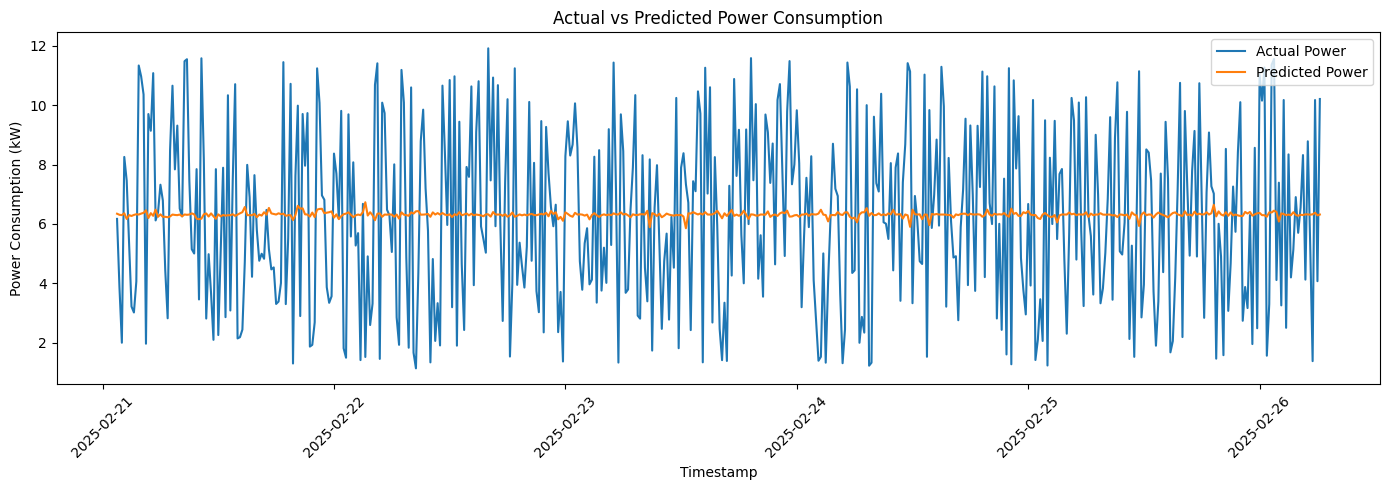

In [39]:
plt.figure(figsize=(14, 5))

plt.plot(
    test_results["Timestamp"].iloc[:500],
    test_results["actual_power"].iloc[:500],
    label="Actual Power"
)

plt.plot(
    test_results["Timestamp"].iloc[:500],
    test_results["predicted_power"].iloc[:500],
    label="Predicted Power"
)

plt.title("Actual vs Predicted Power Consumption")
plt.xlabel("Timestamp")
plt.ylabel("Power Consumption (kW)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Residual analysis

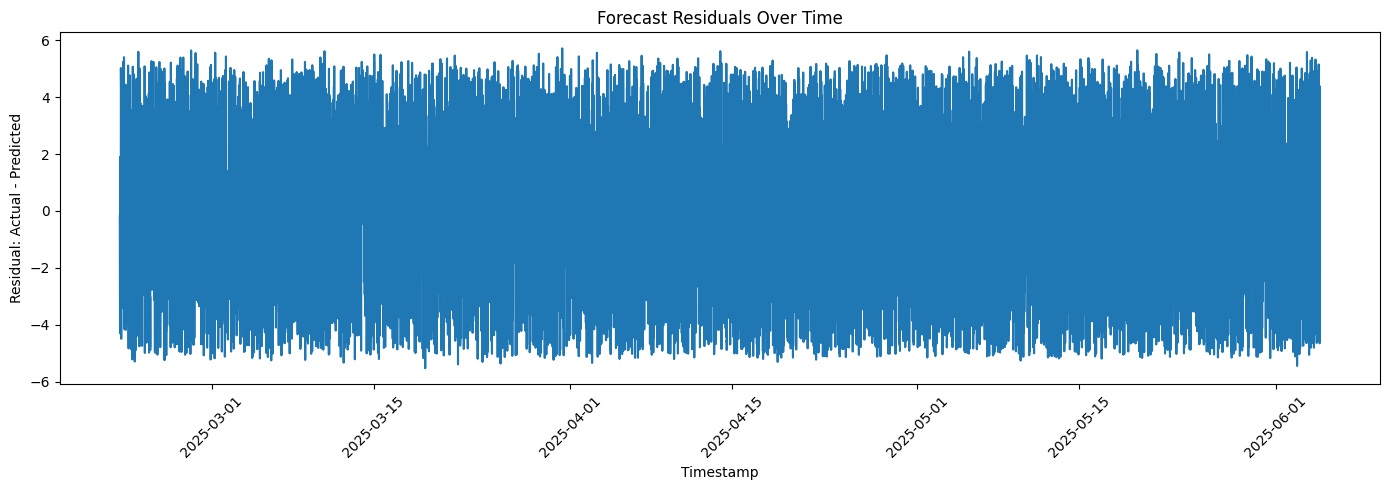

In [40]:
plt.figure(figsize=(14, 5))

plt.plot(
    test_results["Timestamp"],
    test_results["residual"]
)

plt.title("Forecast Residuals Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Residual: Actual - Predicted")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Anomaly threshold

In [41]:
train_predictions = hgb_model.predict(X_train_safe)

train_residuals = y_train.values - train_predictions
train_abs_residuals = np.abs(train_residuals)

anomaly_threshold = float(np.percentile(train_abs_residuals, 95))

anomaly_threshold

4.88865720313224

## Flag anomalies in test set

In [42]:
test_results["is_anomaly"] = (test_results["abs_residual"] > anomaly_threshold).astype(int)

test_results["is_anomaly"].value_counts()

is_anomaly
0    9393
1     569
Name: count, dtype: int64

In [43]:
anomaly_rate = test_results["is_anomaly"].mean() * 100

print(f"Anomaly rate in test set: {anomaly_rate:.2f}%")

Anomaly rate in test set: 5.71%


## First anomalies

In [44]:
anomalies = test_results[test_results["is_anomaly"] == 1]

anomalies[[
    "Timestamp",
    "actual_power",
    "predicted_power",
    "residual",
    "abs_residual",
    "Overload Condition",
    "Transformer Fault"
]].head(20)

,Timestamp,actual_power,predicted_power,residual,abs_residual,Overload Condition,Transformer Fault
39856,2025-02-21 03:45:00,11.339998,6.317005,5.022993,5.022993,0,0
39875,2025-02-21 08:30:00,11.484729,6.319323,5.165405,5.165405,0,0
39876,2025-02-21 08:45:00,11.551457,6.308052,5.243405,5.243405,0,0
39882,2025-02-21 10:15:00,11.582885,6.177616,5.405269,5.405269,0,0
39916,2025-02-21 18:45:00,11.452596,6.344614,5.107982,5.107982,0,0
39950,2025-02-22 03:15:00,1.516718,6.732143,-5.215425,5.215425,0,0
39955,2025-02-22 04:30:00,11.413505,6.344614,5.068891,5.068891,0,0
39956,2025-02-22 04:45:00,1.452196,6.354309,-4.902113,4.902113,0,0
39971,2025-02-22 08:30:00,1.133701,6.426155,-5.292454,5.292454,0,0
39977,2025-02-22 10:00:00,1.334355,6.241937,-4.907582,4.907582,0,0


## Plot residuals with threshold

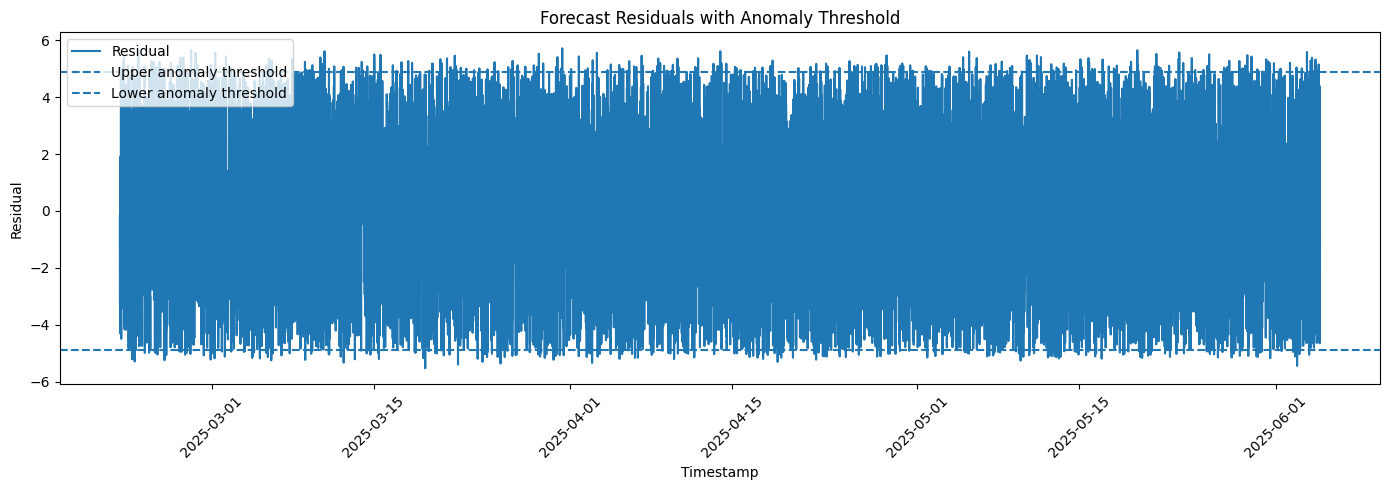

In [45]:
plt.figure(figsize=(14, 5))

plt.plot(test_results["Timestamp"], test_results["residual"], label="Residual")

plt.axhline(anomaly_threshold, linestyle="--", label="Upper anomaly threshold")

plt.axhline(-anomaly_threshold, linestyle="--",label="Lower anomaly threshold")

plt.title("Forecast Residuals with Anomaly Threshold")
plt.xlabel("Timestamp")
plt.ylabel("Residual")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Compare anomalies with overload/transformer fault

In [46]:
pd.crosstab(test_results["is_anomaly"], test_results["Overload Condition"],
    rownames=["Forecast Anomaly"],
    colnames=["Overload Condition"])

Overload Condition,0,1
Forecast Anomaly,,
0,8436,957
1,510,59


In [47]:
pd.crosstab(test_results["is_anomaly"], test_results["Transformer Fault"],
    rownames=["Forecast Anomaly"],
    colnames=["Transformer Fault"])

Transformer Fault,0,1
Forecast Anomaly,,
0,9111,282
1,546,23


The anomaly detection approach is based on forecast residuals. A point is flagged as anomalous when the absolute difference between actual and predicted power consumption exceeds the anomaly threshold estimated from training residuals.

The forecast-based anomalies do not perfectly match the Overload Condition or Transformer Fault indicators. This is expected, because the model was not trained as a supervised fault classifier. Instead, it identifies time points where consumption behavior deviates significantly from the expected pattern.

In [48]:
summary = {
    "anomaly_threshold": float(anomaly_threshold),
    "test_samples": len(test_results),
    "normal_points": int((test_results["is_anomaly"] == 0).sum()),
    "anomaly_points": int((test_results["is_anomaly"] == 1).sum()),
    "anomaly_rate_percent": float(anomaly_rate),
}

summary

{'anomaly_threshold': 4.88865720313224,
 'test_samples': 9962,
 'normal_points': 9393,
 'anomaly_points': 569,
 'anomaly_rate_percent': 5.711704477012648}